Here we will check some

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
plt.style.use('default')

df = pd.read_csv('../data/raw/clean_data.csv')

In [88]:
df.isna().sum()

Unnamed: 0                      0
year                            0
quarter                         0
station                         0
irg                             0
irg_index                       0
iodine_ radionuclides           0
stable_radionuclides            0
stable_ radionuclides_index     0
cs_137_emission                 0
co_60_ emission                 0
cs_137_dump                     0
co_60_dump                     17
volume                          0
index_radioactive_releas        0
index_dump                      0
dtype: int64

In [89]:
df.dtypes

Unnamed: 0                       int64
year                             int64
quarter                          int64
station                            str
irg                            float64
irg_index                      float64
iodine_ radionuclides          float64
stable_radionuclides           float64
stable_ radionuclides_index    float64
cs_137_emission                float64
co_60_ emission                float64
cs_137_dump                    float64
co_60_dump                     float64
volume                         float64
index_radioactive_releas       float64
index_dump                     float64
dtype: object

In [90]:
df['co_60_dump'] = df['co_60_dump'].fillna(df['co_60_dump'].mean())

In [91]:
df.isna().sum()

Unnamed: 0                     0
year                           0
quarter                        0
station                        0
irg                            0
irg_index                      0
iodine_ radionuclides          0
stable_radionuclides           0
stable_ radionuclides_index    0
cs_137_emission                0
co_60_ emission                0
cs_137_dump                    0
co_60_dump                     0
volume                         0
index_radioactive_releas       0
index_dump                     0
dtype: int64

In [92]:
df.columns

Index(['Unnamed: 0', 'year', 'quarter', 'station', 'irg', 'irg_index',
       'iodine_ radionuclides', 'stable_radionuclides',
       'stable_ radionuclides_index', 'cs_137_emission', 'co_60_ emission',
       'cs_137_dump', 'co_60_dump', 'volume', 'index_radioactive_releas',
       'index_dump'],
      dtype='str')

In [93]:
df.dtypes

Unnamed: 0                       int64
year                             int64
quarter                          int64
station                            str
irg                            float64
irg_index                      float64
iodine_ radionuclides          float64
stable_radionuclides           float64
stable_ radionuclides_index    float64
cs_137_emission                float64
co_60_ emission                float64
cs_137_dump                    float64
co_60_dump                     float64
volume                         float64
index_radioactive_releas       float64
index_dump                     float64
dtype: object

In [94]:
columns = ['irg', 'irg_index',
           'iodine_ radionuclides',
           'stable_radionuclides', 'stable_ radionuclides_index',
           'cs_137_emission', 'co_60_ emission', 'cs_137_dump', 'co_60_dump',
           'volume', 'index_radioactive_releas', 'index_dump']

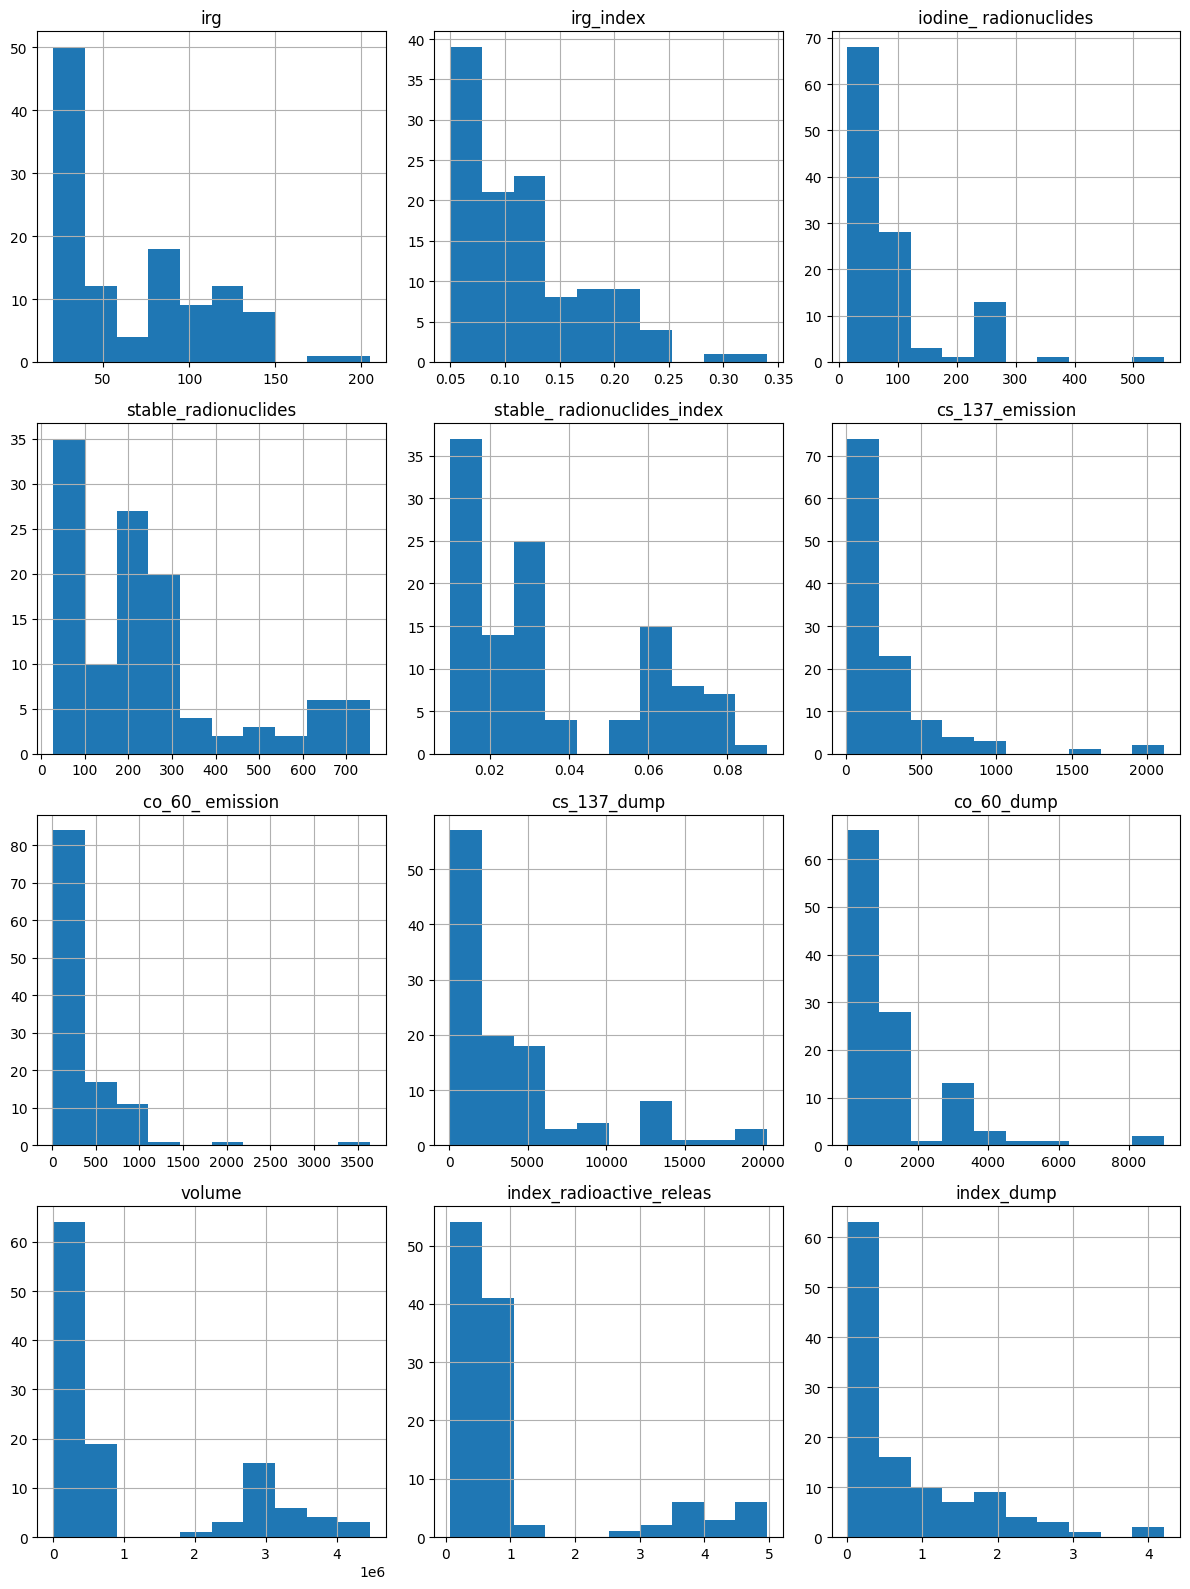

In [95]:
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

for i, column in enumerate(columns):
    df[column].hist(ax=axes[i])
    axes[i].set_title(column)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/data_distributions.png')
plt.show()

Explore the analysis questions

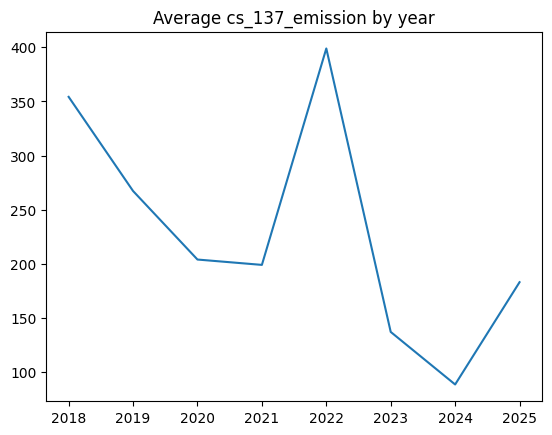

In [96]:
# avg cs-137 emission through years

avg_cs137 = df.groupby(df['year'])['cs_137_emission'].mean()
plt.plot(avg_cs137)
plt.title('Average cs_137_emission by year')
plt.savefig('../reports/figures/cs_137_emission_by_year.png')
plt.show()

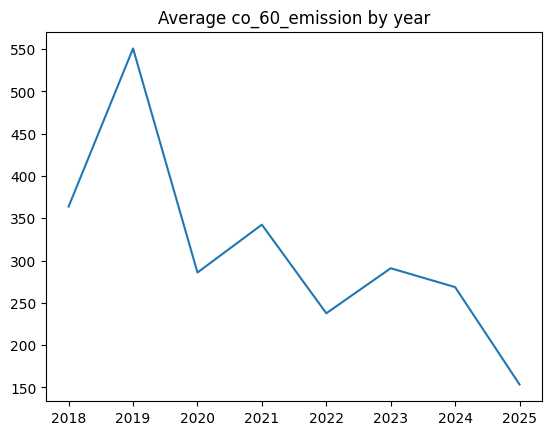

In [97]:
# avg co-60 emission through years

avg_co60 = df.groupby(df['year'])['co_60_ emission'].mean()
plt.plot(avg_co60)
plt.title('Average co_60_emission by year')
plt.savefig('../reports/figures/co_60_emission_by_year.png')
plt.show()

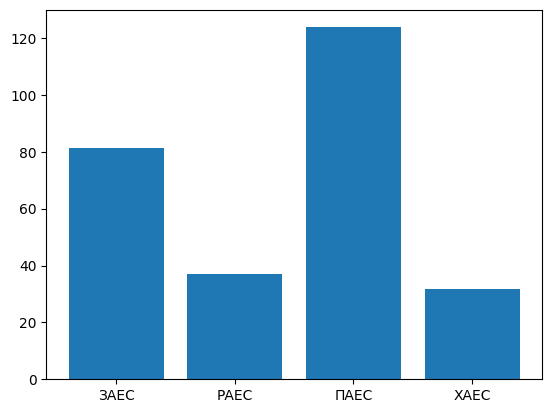

In [98]:
station_irg = df.groupby(df['station'])['irg'].mean()
stations = df['station'].unique()
plt.bar(stations, station_irg)
plt.savefig('../reports/figures/avg_irg_by_station.png')
plt.show()

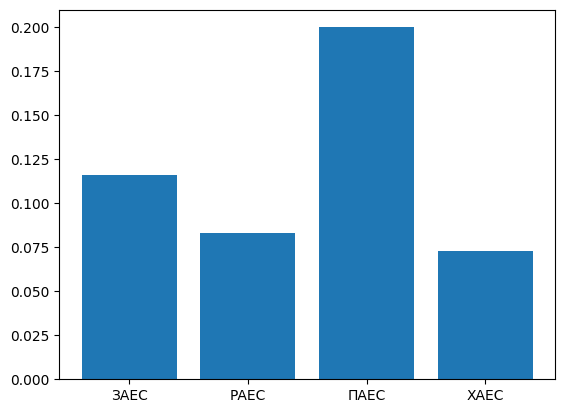

In [99]:
station_irg_indx = df.groupby(df['station'])['irg_index'].mean()
stations = df['station'].unique()
plt.bar(stations, station_irg_indx)
plt.savefig('../reports/figures/avg_irg_indx_by_station.png')
plt.show()

Try to find some correlations or good visualizations

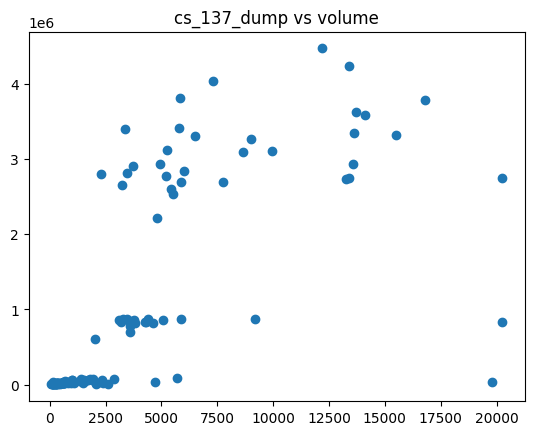

In [100]:
plt.figure()
plt.scatter(df['cs_137_dump'], df['volume'])
plt.title('cs_137_dump vs volume')
plt.show()

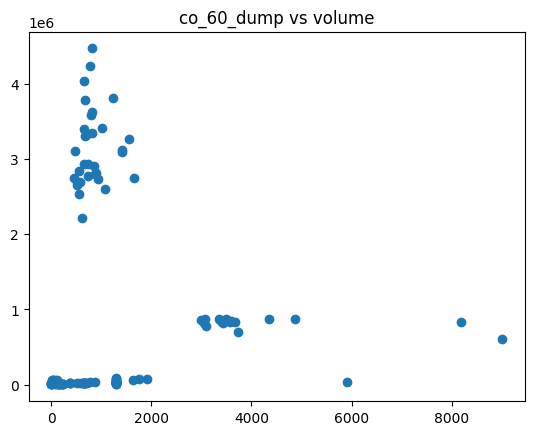

In [101]:
plt.figure()
plt.scatter(df['co_60_dump'], df['volume'])
plt.title('co_60_dump vs volume')
plt.show()

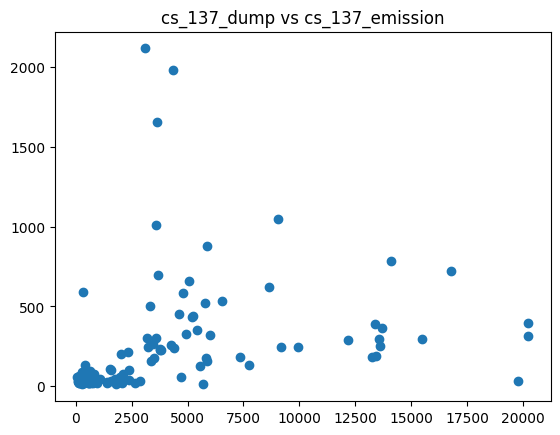

In [102]:
plt.figure()
plt.scatter(df['cs_137_dump'], df['cs_137_emission'])
plt.title('cs_137_dump vs cs_137_emission')
plt.show()

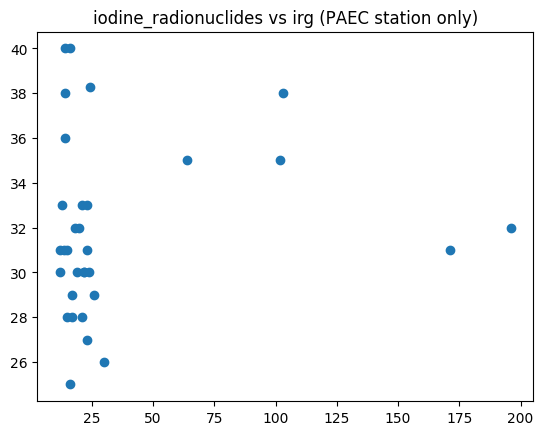

In [103]:
plt.figure()
# Create boolean mask
mask = df['station'] == 'ХАЕС'
# Use mask for both x and y
plt.scatter(df.loc[mask, 'co_60_ emission'], df.loc[mask, 'irg'])
plt.title('iodine_radionuclides vs irg (РАЕС station only)')
plt.show()

Use PCA for data visualization try

In [104]:
df_scaled = df.drop(['station'], axis=1)
scaler = StandardScaler()
scaler.fit(df_scaled)
df_scaled = scaler.transform(df_scaled)

In [105]:
pca = PCA(0.90)
df_pca = pca.fit_transform(df_scaled)
df_pca

array([[ 3.50236137e+00, -3.92062449e+00, -9.04235150e-01,
        -2.91589544e+00,  3.87811377e-01, -3.50302586e-01,
        -1.76401642e+00],
       [ 2.31110039e+00, -5.81391643e-01, -1.70438730e+00,
        -3.47544599e-01,  5.76195096e-01,  5.15221048e-04,
         9.24352433e-01],
       [-8.93349818e-01, -1.06922321e+00, -2.45971189e+00,
         1.81803239e-02,  9.90528230e-01, -3.36449210e-01,
         4.19117556e-01],
       [-1.75765759e+00, -1.05596653e+00, -2.73757059e+00,
         1.00435264e-02,  5.16002190e-01,  6.26321768e-01,
         3.91989493e-01],
       [ 2.13583337e+00, -3.38559687e+00, -3.85300034e-01,
        -4.73312870e-01,  3.34792169e-01, -1.00350607e+00,
         1.94899117e-01],
       [ 2.97095343e+00,  1.50776077e-01, -1.30919059e+00,
         1.22156524e+00,  5.97493082e-01,  1.36990774e+00,
         8.95715301e-01],
       [-7.83252018e-01, -1.38193065e+00, -1.63015723e+00,
         8.35855778e-01,  7.30121790e-01, -3.11819828e-01,
         7.3439268

In [106]:
pca.explained_variance_ratio_

array([0.33272071, 0.18618127, 0.14739684, 0.08802591, 0.06535302,
       0.04847032, 0.04025776])

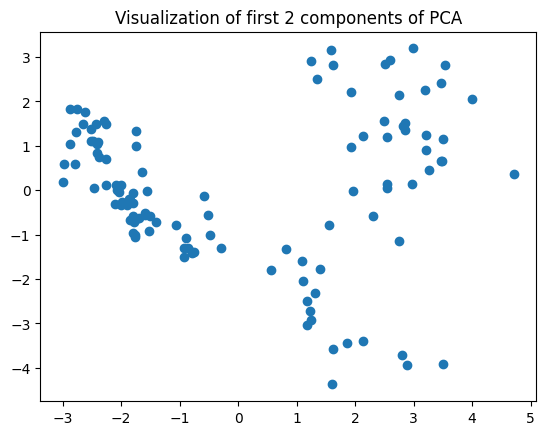

In [107]:
plt.scatter(df_pca[:, 0], df_pca[:, 1])
plt.title('Visualization of first 2 components of PCA')
plt.show()

Unfortunately information in data is distributed among the majority of features so the 2d pca visualization is not very helpful

The correlation matrix heatmap will be more helpful in seeing patterns

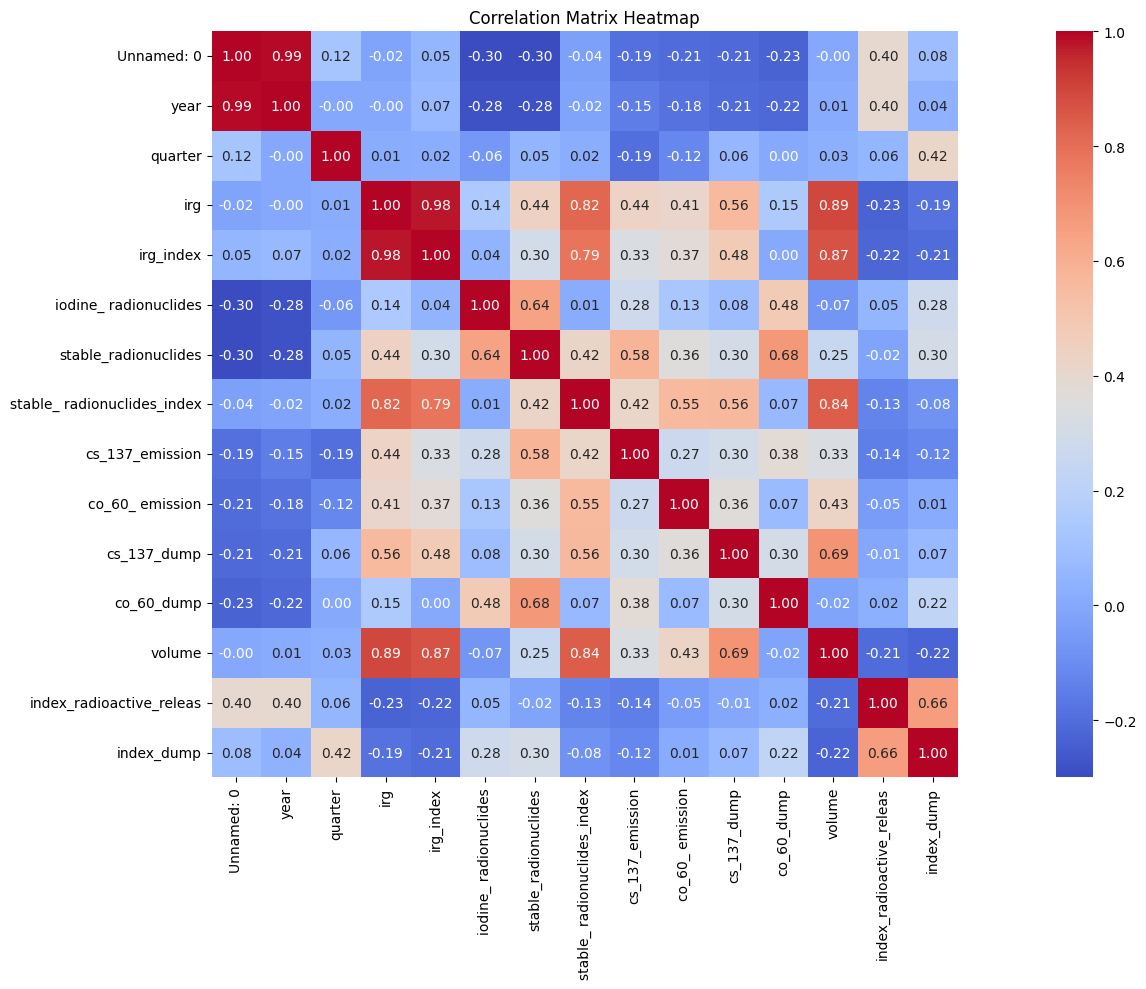

In [108]:
df_corr = df.drop(['station'], axis=1)
corr_matr = df_corr.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png')
plt.show()